In [275]:
## IMPORTING LIBRARIES

# Core Libraries
import pandas as pd
import numpy as np
import seaborn as sns
import matplotlib.pyplot as plt

# Model Selection
from sklearn.model_selection import train_test_split, cross_val_score

# Preprocessing
from sklearn.preprocessing import StandardScaler
from sklearn.pipeline import Pipeline

# Models
from sklearn.linear_model import LogisticRegression
from sklearn.tree import DecisionTreeClassifier
from sklearn.ensemble import RandomForestClassifier

# Evaluation Metrics
from sklearn.metrics import accuracy_score, confusion_matrix, classification_report, roc_auc_score

# Model Saving
import joblib

In [277]:
# Loading Dataset
df = pd.read_csv("heart.csv")
df.head()

,age,sex,cp,trestbps,chol,fbs,restecg,thalach,exang,oldpeak,slope,ca,thal,target
0,52,1,0,125,212,0,1,168,0,1.0,2,2,3,0
1,53,1,0,140,203,1,0,155,1,3.1,0,0,3,0
2,70,1,0,145,174,0,1,125,1,2.6,0,0,3,0
3,61,1,0,148,203,0,1,161,0,0.0,2,1,3,0
4,62,0,0,138,294,1,1,106,0,1.9,1,3,2,0


In [279]:
df.shape

(1025, 14)

In [281]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 1025 entries, 0 to 1024
Data columns (total 14 columns):
 #   Column    Non-Null Count  Dtype  
---  ------    --------------  -----  
 0   age       1025 non-null   int64  
 1   sex       1025 non-null   int64  
 2   cp        1025 non-null   int64  
 3   trestbps  1025 non-null   int64  
 4   chol      1025 non-null   int64  
 5   fbs       1025 non-null   int64  
 6   restecg   1025 non-null   int64  
 7   thalach   1025 non-null   int64  
 8   exang     1025 non-null   int64  
 9   oldpeak   1025 non-null   float64
 10  slope     1025 non-null   int64  
 11  ca        1025 non-null   int64  
 12  thal      1025 non-null   int64  
 13  target    1025 non-null   int64  
dtypes: float64(1), int64(13)
memory usage: 112.2 KB


In [283]:
df.describe()

,age,sex,cp,trestbps,chol,fbs,restecg,thalach,exang,oldpeak,slope,ca,thal,target
count,1025.000000,1025.000000,1025.000000,1025.000000,1025.00000,1025.000000,1025.000000,1025.000000,1025.000000,1025.000000,1025.000000,1025.000000,1025.000000,1025.000000
mean,54.434146,0.695610,0.942439,131.611707,246.00000,0.149268,0.529756,149.114146,0.336585,1.071512,1.385366,0.754146,2.323902,0.513171
std,9.072290,0.460373,1.029641,17.516718,51.59251,0.356527,0.527878,23.005724,0.472772,1.175053,0.617755,1.030798,0.620660,0.500070
min,29.000000,0.000000,0.000000,94.000000,126.00000,0.000000,0.000000,71.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000
25%,48.000000,0.000000,0.000000,120.000000,211.00000,0.000000,0.000000,132.000000,0.000000,0.000000,1.000000,0.000000,2.000000,0.000000
50%,56.000000,1.000000,1.000000,130.000000,240.00000,0.000000,1.000000,152.000000,0.000000,0.800000,1.000000,0.000000,2.000000,1.000000
75%,61.000000,1.000000,2.000000,140.000000,275.00000,0.000000,1.000000,166.000000,1.000000,1.800000,2.000000,1.000000,3.000000,1.000000
max,77.000000,1.000000,3.000000,200.000000,564.00000,1.000000,2.000000,202.000000,1.000000,6.200000,2.000000,4.000000,3.000000,1.000000


In [285]:
#CHECKING NULL VALUES
df.isnull().sum().sort_values(ascending=False)

age         0
sex         0
cp          0
trestbps    0
chol        0
fbs         0
restecg     0
thalach     0
exang       0
oldpeak     0
slope       0
ca          0
thal        0
target      0
dtype: int64

In [287]:
# Data Profilling 
from ydata_profiling import ProfileReport

profile = ProfileReport(df, explorative=True)
profile.to_file("Heart_Disease_report.html")

Summarize dataset:   0%|          | 0/5 [00:00<?, ?it/s]


100%|██████████| 14/14 [00:00<00:00, 82.47it/s][A


Generate report structure:   0%|          | 0/1 [00:00<?, ?it/s]

Render HTML:   0%|          | 0/1 [00:00<?, ?it/s]

Export report to file:   0%|          | 0/1 [00:00<?, ?it/s]

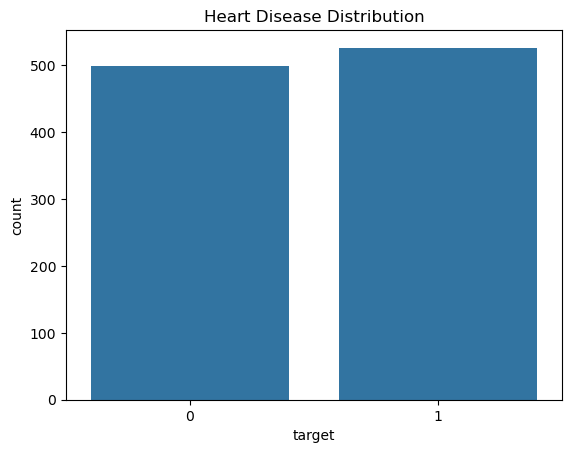

In [288]:
#VISUALIZATION
sns.countplot(x='target', data=df)
plt.title("Heart Disease Distribution")
plt.show()


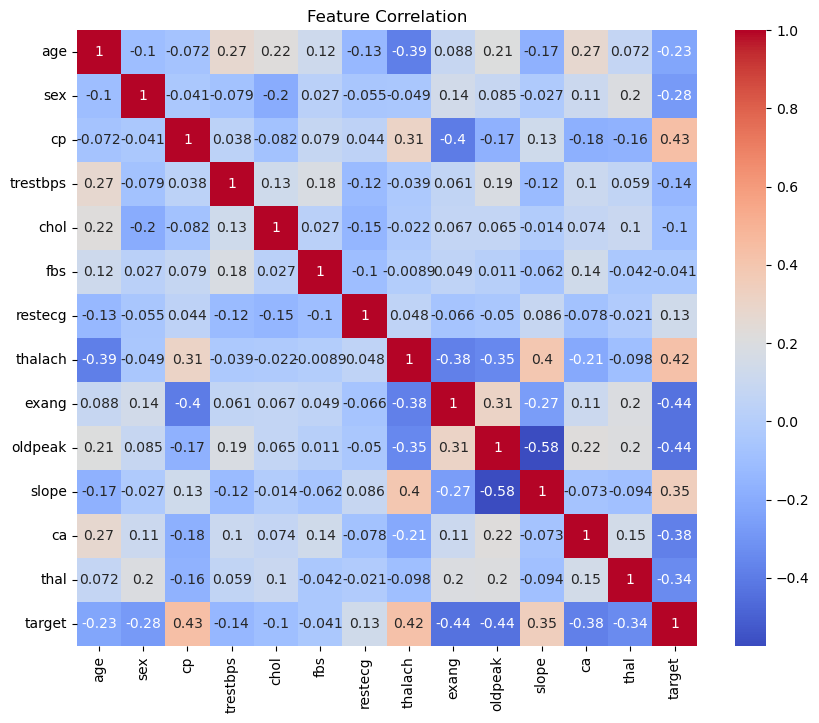

In [289]:
# Correlation Heatmap
plt.figure(figsize=(10,8))
sns.heatmap(df.corr(), annot=True, cmap='coolwarm')
plt.title("Feature Correlation")
plt.show()

In [290]:
# SPLITTING THE DATA
X = df.drop("target", axis=1)
y = df["target"]

X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42
)

In [291]:
# CREATING PIPELINES
models = {
    "Logistic Regression": Pipeline([
        ('scaler', StandardScaler()),
        ('model', LogisticRegression(max_iter=2000))
    ]),
    
    "Decision Tree": Pipeline([
        ('model', DecisionTreeClassifier(max_depth=4, random_state=42))
    ]),
    
    "Random Forest": Pipeline([
        ('model', RandomForestClassifier(max_depth=4, n_estimators=100, random_state=42))
    ])
}

results = {}

In [292]:
#TRAINING THE MODEL
trained_models = {}

for name, model in models.items():
    model.fit(X_train, y_train)
    trained_models[name] = model

In [293]:
#EVALUTING MODEL
results = {}

for name, model in trained_models.items():
    y_pred = model.predict(X_test)
    
    acc = accuracy_score(y_test, y_pred)
    roc = roc_auc_score(y_test, y_pred)
    
    results[name] = acc
    
    print(f"\n{name}")
    print("Accuracy:", acc)
    print("ROC-AUC Score:", roc)
    print("Confusion Matrix:\n", confusion_matrix(y_test, y_pred))
    print("Classification Report:\n", classification_report(y_test, y_pred))


Logistic Regression
Accuracy: 0.7951219512195122
ROC-AUC Score: 0.7947363411383972
Confusion Matrix:
 [[73 29]
 [13 90]]
Classification Report:
               precision    recall  f1-score   support

           0       0.85      0.72      0.78       102
           1       0.76      0.87      0.81       103

    accuracy                           0.80       205
   macro avg       0.80      0.79      0.79       205
weighted avg       0.80      0.80      0.79       205


Decision Tree
Accuracy: 0.8
ROC-AUC Score: 0.7994955263658862
Confusion Matrix:
 [[71 31]
 [10 93]]
Classification Report:
               precision    recall  f1-score   support

           0       0.88      0.70      0.78       102
           1       0.75      0.90      0.82       103

    accuracy                           0.80       205
   macro avg       0.81      0.80      0.80       205
weighted avg       0.81      0.80      0.80       205


Random Forest
Accuracy: 0.8390243902439024
ROC-AUC Score: 0.83866362078812

In [294]:
#CROSS VALIDATION
for name, model in models.items():
    score = cross_val_score(model, X, y, cv=5)
    print(f"{name} CV Score:", score.mean())

Logistic Regression CV Score: 0.8458536585365855
Decision Tree CV Score: 0.8341463414634147
Random Forest CV Score: 0.8946341463414635


In [295]:
# SELECTING BEST MODEL
best_model = max(results, key=results.get)
print("Best Model:", best_model)


Best Model: Random Forest


In [296]:
# TRAINING THE FINAL MODEL
final_model = models[best_model]
final_model.fit(X_train, y_train)


Pipeline(steps=[('model',
                 RandomForestClassifier(max_depth=4, random_state=42))])

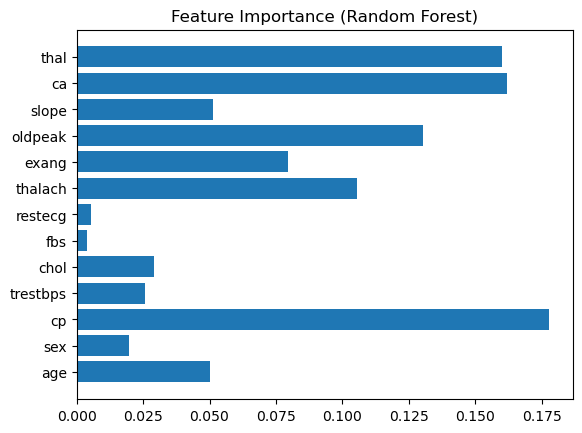

In [297]:
model = final_model.named_steps['model']  
importances = model.feature_importances_
features = X.columns
plt.barh(features, importances)
plt.title("Feature Importance (Random Forest)")
plt.show()

In [298]:
# SAVING THE MODEL
joblib.dump(final_model, "heart_model.pkl")

print("\n✅ Model saved successfully as heart_model.pkl")


✅ Model saved successfully as heart_model.pkl
